<div style="text-align:center;">

<h1 style="
background: linear-gradient(to right, #07ccfd);
color: white;
padding: 15px 30px;
border-radius: 14px;
font-family: 'Trebuchet MS', sans-serif;
letter-spacing: 1px;
box-shadow: 0px 4px 10px rgba(0,0,0,0.2);
display: inline-block;
margin: 10px auto;
">
Student Academic Performance Prediction Using ML 👨🏻‍🎓
</h1>

</div>


<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Importing Libraries
</h3>


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')

<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Dataset Loading and Understanding
</h3>


In [3]:
df = pd.read_csv(r"C:\Users\tatak\haroon\DATASETS\xAPI-Edu-Data.csv")
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [4]:
df.shape

(480, 17)

In [5]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   gender                    480 non-null    str  
 1   NationalITy               480 non-null    str  
 2   PlaceofBirth              480 non-null    str  
 3   StageID                   480 non-null    str  
 4   GradeID                   480 non-null    str  
 5   SectionID                 480 non-null    str  
 6   Topic                     480 non-null    str  
 7   Semester                  480 non-null    str  
 8   Relation                  480 non-null    str  
 9   raisedhands               480 non-null    int64
 10  VisITedResources          480 non-null    int64
 11  AnnouncementsView         480 non-null    int64
 12  Discussion                480 non-null    int64
 13  ParentAnsweringSurvey     480 non-null    str  
 14  ParentschoolSatisfaction  480 non-null    str  
 15  

In [7]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [8]:
print(df['Class'].unique())


<ArrowStringArray>
['M', 'L', 'H']
Length: 3, dtype: str


<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Data Cleaning
</h3>


In [9]:
df.drop(['NationalITy', 'PlaceofBirth', 'SectionID'], axis=1, inplace=True)

print(df.columns)

Index(['gender', 'StageID', 'GradeID', 'Topic', 'Semester', 'Relation',
       'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='str')


In [10]:
df.head()

,gender,StageID,GradeID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,lowerlevel,G-04,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,lowerlevel,G-04,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,lowerlevel,G-04,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,lowerlevel,G-04,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,lowerlevel,G-04,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [11]:
df.isna().sum()

gender                      0
StageID                     0
GradeID                     0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

In [12]:
datadict=pd.DataFrame(df.dtypes)
datadict['Missing value']=df.isna().sum()
datadict['N Unique']=df.nunique()
datadict['Count']=df.count()
datadict=datadict.rename(columns={0:'DataType'})
datadict

,DataType,Missing value,N Unique,Count
gender,str,0,2,480
StageID,str,0,3,480
GradeID,str,0,10,480
Topic,str,0,12,480
Semester,str,0,2,480
Relation,str,0,2,480
raisedhands,int64,0,82,480
VisITedResources,int64,0,89,480
AnnouncementsView,int64,0,88,480
Discussion,int64,0,90,480


In [13]:
num_col=df.select_dtypes(include='number')
num_col

,raisedhands,VisITedResources,AnnouncementsView,Discussion
0,15,16,2,20
1,20,20,3,25
2,10,7,0,30
3,30,25,5,35
4,40,50,12,50
...,...,...,...,...
475,5,4,5,8
476,50,77,14,28
477,55,74,25,29
478,30,17,14,57


### Average raised hands based on performance class


In [14]:
df.groupby('Class')['raisedhands'].mean()

Class
H    70.288732
L    16.889764
M    48.938389
Name: raisedhands, dtype: float64

<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Outliler Checking
</h3>


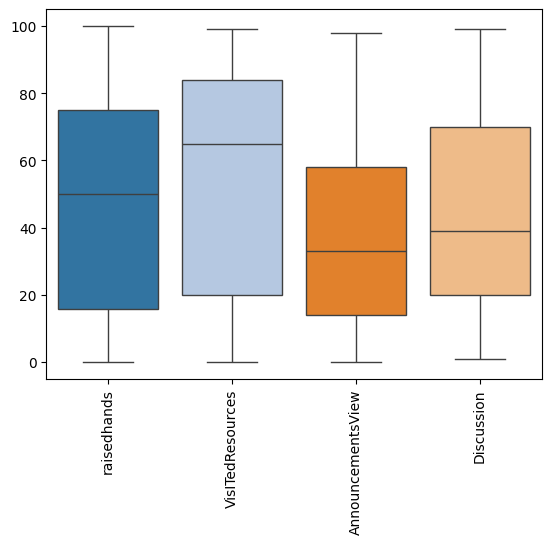

In [15]:
sns.boxplot(data=df, palette="tab20")
plt.xticks(rotation=90)
plt.show()

<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
EDA
</h3>


### Student Performance


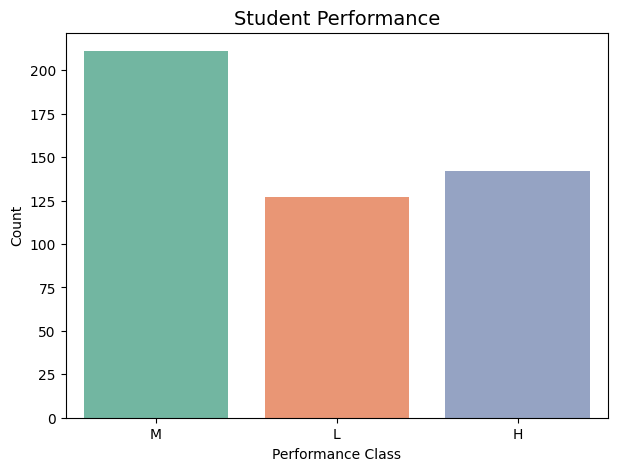

In [16]:
plt.figure(figsize=(7,5))
sns.countplot(x='Class',data=df,palette='Set2')
plt.title("Student Performance", fontsize=14)
plt.xlabel("Performance Class")
plt.ylabel("Count")
plt.show()

**Most students fall into the medium performance category, while a good number achieve high performance. Fewer students show low academic performance.**

### Student Absence by Performance


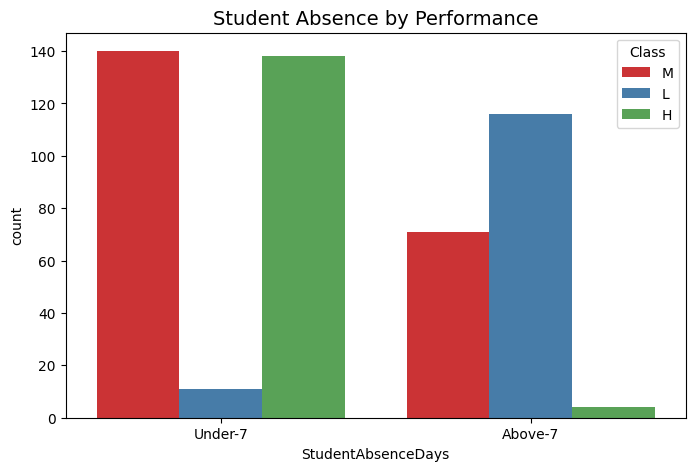

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='StudentAbsenceDays',hue='Class',data=df,palette='Set1')
plt.title("Student Absence by Performance", fontsize=14)
plt.show()

**Higher attendance is strongly associated with better student performance. Students absent for more than 7 days tend to perform poorly.**

### Correlation HeatMap


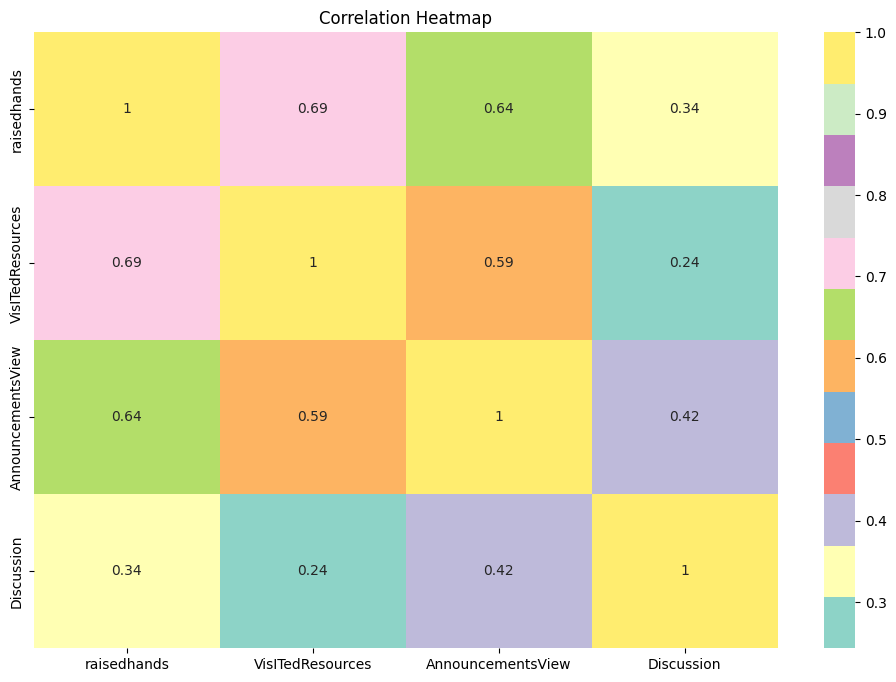

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(num_col.corr(), annot=True,cmap='Set3')
plt.title("Correlation Heatmap")
plt.show()

* Student participation, resource usage, and announcement checking are strongly connected.
* Discussion activity has a weaker relationship with other learning behaviors.
* Higher engagement usually indicates better academic involvement and performance.

<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Encoding
</h3>


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   gender                    480 non-null    str  
 1   StageID                   480 non-null    str  
 2   GradeID                   480 non-null    str  
 3   Topic                     480 non-null    str  
 4   Semester                  480 non-null    str  
 5   Relation                  480 non-null    str  
 6   raisedhands               480 non-null    int64
 7   VisITedResources          480 non-null    int64
 8   AnnouncementsView         480 non-null    int64
 9   Discussion                480 non-null    int64
 10  ParentAnsweringSurvey     480 non-null    str  
 11  ParentschoolSatisfaction  480 non-null    str  
 12  StudentAbsenceDays        480 non-null    str  
 13  Class                     480 non-null    str  
dtypes: int64(4), str(10)
memory usage: 72.1 KB


In [20]:
le = LabelEncoder()

categorical_columns = ['gender','StageID','GradeID','Topic','Semester','Relation','ParentAnsweringSurvey','ParentschoolSatisfaction',
                       'StudentAbsenceDays','Class']
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,StageID,GradeID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,1,2,1,7,0,0,15,16,2,20,1,1,1,2
1,1,2,1,7,0,0,20,20,3,25,1,1,1,2
2,1,2,1,7,0,0,10,7,0,30,0,0,0,1
3,1,2,1,7,0,0,30,25,5,35,0,0,0,1
4,1,2,1,7,0,0,40,50,12,50,0,0,0,2


<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Scaling
</h3>


In [21]:
df.columns


Index(['gender', 'StageID', 'GradeID', 'Topic', 'Semester', 'Relation',
       'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='str')

In [22]:
sc=StandardScaler()
cols=['gender', 'StageID', 'GradeID', 'Topic', 'Semester', 'Relation',
       'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays']
for i in cols:
    df[i]=sc.fit_transform(df[[i]])

In [23]:
sd=sc.fit_transform(df[cols])
df[['gender', 'StageID', 'GradeID', 'Topic', 'Semester', 'Relation',
       'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays']]=pd.DataFrame(sd,columns=cols)

<h3 style="
background: linear-gradient(to right, #07ccfd); 
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Train test split
</h3>


In [24]:
x = df.drop('Class', axis=1)
y = df['Class']

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Model Building
</h3>


## Logistic Regression


In [26]:
model_logistic= LogisticRegression()

In [27]:
model_logistic=model_logistic.fit(x_train,y_train)
y_logistic=model_logistic.predict(x_test)

In [28]:
lr_accuracy = accuracy_score(y_test, y_logistic)
print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.8229166666666666


## RandomForest Classifier


In [29]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

In [30]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.84375


## XGBoost


In [31]:
xgb_model = XGBClassifier( eval_metric='mlogloss',andom_state=42)
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_test)

In [32]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy :", xgb_accuracy)

XGBoost Accuracy : 0.8333333333333334


<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Final Comparison Table
</h3>


In [33]:
from tabulate import tabulate
table=[['Model','Accuracy'],['Logistic Regression',lr_accuracy],
       ['Random Forest ',rf_accuracy],
       ['XGB',xgb_accuracy]]
print(tabulate(table,headers='firstrow',tablefmt="github"))

| Model               |   Accuracy |
|---------------------|------------|
| Logistic Regression |   0.822917 |
| Random Forest       |   0.84375  |
| XGB                 |   0.833333 |


<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Model Tuning
</h3>


### Grid Search CV


In [34]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

In [35]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [36]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100}


In [37]:
finalmodel=RandomForestClassifier(n_estimators=100,max_depth=15,min_samples_split=5)
finalmodel.fit(x_train,y_train)
y_pred=finalmodel.predict(x_test)
finalaccuracy=accuracy_score(y_test,y_pred)
print("Tuned Random Forest Accuracy :", finalaccuracy)

Tuned Random Forest Accuracy : 0.84375


### Randomized Search CV


In [38]:
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [39]:
random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),param_distributions=param_dist,n_iter=10,cv=5,verbose=2,random_state=42,n_jobs=-1)
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... version

In [40]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}


In [41]:
finalmodel1=RandomForestClassifier(n_estimators=100,max_depth=20,min_samples_split=20,min_samples_leaf=1)
finalmodel1.fit(x_train,y_train)
y_pred1=finalmodel1.predict(x_test)
finalaccuracy1=accuracy_score(y_test,y_pred1)
print("Tuned Random Forest Accuracy :", finalaccuracy1)

Tuned Random Forest Accuracy : 0.8541666666666666


<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Classification Report
</h3>


In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.64      0.72        22
           1       0.89      0.96      0.93        26
           2       0.82      0.88      0.85        48

    accuracy                           0.84        96
   macro avg       0.85      0.82      0.83        96
weighted avg       0.84      0.84      0.84        96



<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Confusion Matrix
</h3>


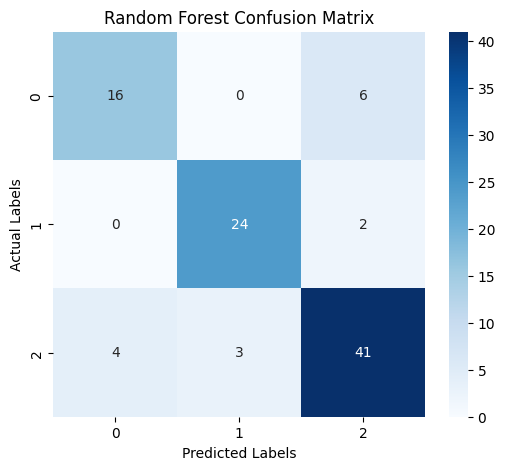

In [43]:
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

<h3 style="
background: linear-gradient(to right, #07ccfd);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
PREDICTION
</h3>


In [44]:
f=x.iloc[0].tolist()
print(f)

[0.757476396862159, 1.0846691145078124, -0.7743636252277124, 0.5151621849017004, -0.9793792286287206, -0.8343339104968389, -1.0334293103052372, -1.1740745633244123, -1.3511665902242826, -0.8433261529989353, 0.8819171036881966, 0.8023936792113683, 0.8129573506520738]


In [45]:
new_data=[[0.757476396862159, 1.0846691145078124, -0.7743636252277124, 0.5151621849017004, -0.9793792286287206, -0.8343339104968389, -1.0334293103052372, -1.1740745633244123, -1.3511665902242826, -0.8433261529989353, 0.8819171036881966, 0.8023936792113683, 0.8129573506520738]]
prediction=finalmodel.predict(new_data)
prediction

array([2])

In [46]:
y

0      2
1      2
2      1
3      1
4      2
      ..
475    1
476    2
477    2
478    1
479    1
Name: Class, Length: 480, dtype: int64